# Level 3 — Statistics

**Dataset:** Synthetic farm-level rainfall and maize yield data, 40 plots split across two zones (Southern Highlands, Central). **This is generated data, not real farm records** — it's built to reflect a well-documented real pattern (Southern Highlands has more reliable rainfall and consistently higher maize yields than the semi-arid Central zone), but the individual numbers are simulated so we have enough data points to do real statistics on.

**What you'll practice:**
- Generating data with `numpy.random` (reproducibly, using a seed)
- Distributions — histograms, boxplots
- Correlation (Pearson's r) and what the p-value actually means
- Hypothesis testing — independent t-test
- Confidence intervals

You'll need `scipy` for this one. If it's not installed:
```
pip install scipy
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)  # reproducibility — same "random" data every run

## 1. Generate the synthetic dataset

Southern Highlands: higher average rainfall (900mm ± 120), and yield responds to rainfall plus some random variation.
Central: lower, less reliable rainfall (550mm ± 150), and generally lower yield.

The yield formula below (`base + slope * rainfall + noise`) is a simplified stand-in for a real agronomic relationship — actual yield depends on soil, seed variety, fertilizer, pests, and more. We're isolating rainfall on purpose so the statistics below have something clean to find.

In [2]:
n_per_zone = 20

# Southern Highlands
sh_rainfall = np.random.normal(loc=900, scale=120, size=n_per_zone)
sh_yield = 0.5 + 0.0022 * sh_rainfall + np.random.normal(0, 0.3, n_per_zone)

# Central
c_rainfall = np.random.normal(loc=550, scale=150, size=n_per_zone)
c_yield = 0.3 + 0.0018 * c_rainfall + np.random.normal(0, 0.3, n_per_zone)

df = pd.DataFrame({
    "Zone": ["Southern Highlands"] * n_per_zone + ["Central"] * n_per_zone,
    "Rainfall_mm": np.concatenate([sh_rainfall, c_rainfall]),
    "Yield_t_per_ha": np.concatenate([sh_yield, c_yield])
})

# Yield can't be negative in reality — clip it
df["Yield_t_per_ha"] = df["Yield_t_per_ha"].clip(lower=0.1)

df.head()

,Zone,Rainfall_mm,Yield_t_per_ha
0,Southern Highlands,959.605698,3.050827
1,Southern Highlands,883.408284,2.375765
2,Southern Highlands,977.722625,2.671248
3,Southern Highlands,1082.763583,2.454655
4,Southern Highlands,871.901595,2.254869


## 2. Look at the distributions

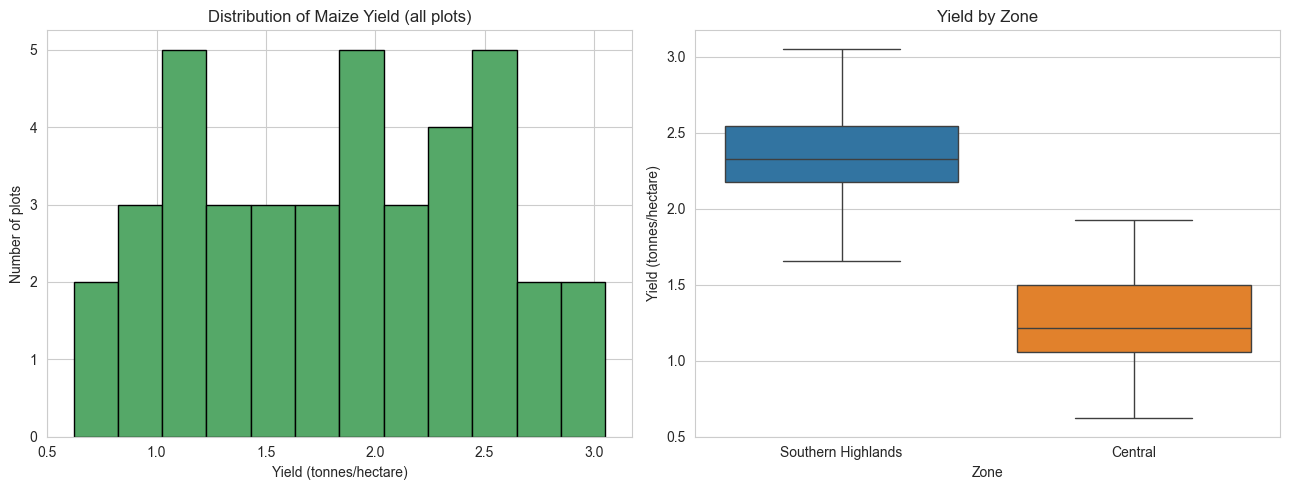

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["Yield_t_per_ha"], bins=12, color="#55A868", edgecolor="black")
axes[0].set_title("Distribution of Maize Yield (all plots)")
axes[0].set_xlabel("Yield (tonnes/hectare)")
axes[0].set_ylabel("Number of plots")

sns.boxplot(data=df, x="Zone", y="Yield_t_per_ha", hue="Zone", legend=False, ax=axes[1])
axes[1].set_title("Yield by Zone")
axes[1].set_ylabel("Yield (tonnes/hectare)")

plt.tight_layout()
plt.show()

The boxplot's middle line is the median, the box spans the 25th–75th percentile (the "middle half" of the data), and the whiskers show the typical range excluding outliers (shown as separate dots if present). This is usually a faster way to compare two groups than eyeballing two overlapping histograms.

## 3. Correlation — does more rainfall mean more yield?

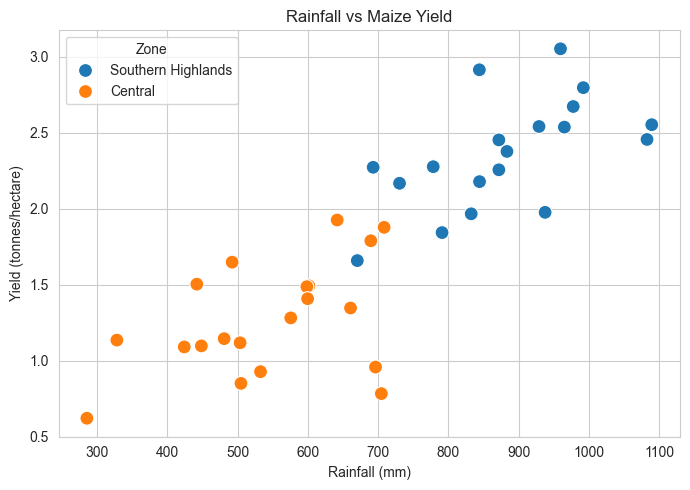

In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_t_per_ha", hue="Zone", s=100)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/hectare)")
plt.title("Rainfall vs Maize Yield")
plt.tight_layout()
plt.show()

In [5]:
r, p_value = stats.pearsonr(df["Rainfall_mm"], df["Yield_t_per_ha"])
print(f"Pearson correlation (r): {r:.3f}")
print(f"p-value: {p_value:.6f}")

Pearson correlation (r): 0.847
p-value: 0.000000


**Reading this:**
- `r` ranges from -1 to 1. Close to 1 means strong positive relationship (more rainfall, more yield), close to 0 means no linear relationship, close to -1 means strong negative relationship.
- The **p-value** answers a different question: "if there were actually no real relationship, how likely is it I'd see a correlation this strong just by chance?" A small p-value (conventionally < 0.05) means the relationship is unlikely to be a fluke.
- Correlation ≠ causation, always — but here we *engineered* the causal link ourselves when generating the data, so finding it back out is a sanity check that the statistics are doing their job correctly.

## 4. Hypothesis test — is the yield difference between zones real?

Southern Highlands plots *look* like they have higher yield in the boxplot above. But with only 20 plots per zone, could that just be random luck in which plots got sampled? An independent t-test answers exactly this.

In [6]:
sh_yields = df[df["Zone"] == "Southern Highlands"]["Yield_t_per_ha"]
central_yields = df[df["Zone"] == "Central"]["Yield_t_per_ha"]

t_stat, p_value = stats.ttest_ind(sh_yields, central_yields)

print(f"Southern Highlands mean yield: {sh_yields.mean():.3f} t/ha")
print(f"Central mean yield: {central_yields.mean():.3f} t/ha")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

Southern Highlands mean yield: 2.355 t/ha
Central mean yield: 1.273 t/ha
t-statistic: 9.490
p-value: 0.000000


**Reading this:**
- The null hypothesis (H₀) is: "there's no real difference between the two zones' average yield."
- If `p_value < 0.05`, we reject H₀ — the difference we're seeing is statistically significant, not just noise.
- The **t-statistic** measures how many standard errors apart the two group means are — bigger absolute value means a more dramatic difference relative to the spread of the data.
- Important: statistical significance isn't the same as practical importance. A tiny, real difference can still be "significant" with enough data. Always look at the actual mean difference (in t/ha here) alongside the p-value, not the p-value alone.

## 5. Confidence interval — how confident are we in the Southern Highlands mean?

In [7]:
confidence = 0.95
mean = sh_yields.mean()
sem = stats.sem(sh_yields)  # standard error of the mean

ci_low, ci_high = stats.t.interval(confidence, df=len(sh_yields) - 1, loc=mean, scale=sem)

print(f"Southern Highlands mean yield: {mean:.3f} t/ha")
print(f"95% confidence interval: [{ci_low:.3f}, {ci_high:.3f}]")

Southern Highlands mean yield: 2.355 t/ha
95% confidence interval: [2.189, 2.521]


This says: "if we repeated this sampling process many times, 95% of the intervals we'd calculate would contain the true population mean." It's a statement about the *procedure's* reliability, not a 95% probability that this specific interval contains the true value — a common mix-up worth avoiding.

## Exercises

1. Run the same t-test, but this time on `Rainfall_mm` instead of yield — is the rainfall difference between zones also statistically significant?
2. Calculate the 95% confidence interval for the Central zone's mean yield, and compare its width to the Southern Highlands one. Which is wider, and why might that be (hint: look at the standard deviations used when generating the data)?
3. Change `n_per_zone` to 5 and rerun the whole notebook from the top. Does the t-test still find a significant difference? What does this tell you about sample size and statistical power?
4. (Challenge) Compute the Pearson correlation separately *within* each zone (not combined). Is it stronger or weaker than the combined correlation from Section 3? Why might combining two zones with different baseline yields inflate or distort a correlation coefficient?

In [8]:
# Your exercise answers here
sh_rainfall_vals = df[df["Zone"] == "Southern Highlands"]["Rainfall_mm"]
central_rainfall_vals = df[df["Zone"] == "Central"]["Rainfall_mm"]

t_stat, p_value = stats.ttest_ind(sh_rainfall_vals, central_rainfall_vals)

print(f"Southern Highlands mean rainfall: {sh_rainfall_vals.mean():.1f} mm")
print(f"Central mean rainfall: {central_rainfall_vals.mean():.1f} mm")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

Southern Highlands mean rainfall: 879.4 mm
Central mean rainfall: 546.0 mm
t-statistic: 8.844
p-value: 0.000000


In [9]:
mean_c = central_yields.mean()
sem_c = stats.sem(central_yields)

ci_low_c, ci_high_c = stats.t.interval(0.95, df=len(central_yields) - 1, loc=mean_c, scale=sem_c)

width_c = ci_high_c - ci_low_c
width_sh = ci_high - ci_low  # from Section 5 above

print(f"Central 95% CI: [{ci_low_c:.3f}, {ci_high_c:.3f}], width = {width_c:.3f}")
print(f"Southern Highlands 95% CI width = {width_sh:.3f}")

Central 95% CI: [1.102, 1.445], width = 0.343
Southern Highlands 95% CI width = 0.331


In [11]:
n_per_zone = 5

In [12]:
r_sh, p_sh = stats.pearsonr(
    df[df["Zone"] == "Southern Highlands"]["Rainfall_mm"],
    df[df["Zone"] == "Southern Highlands"]["Yield_t_per_ha"]
)

r_c, p_c = stats.pearsonr(
    df[df["Zone"] == "Central"]["Rainfall_mm"],
    df[df["Zone"] == "Central"]["Yield_t_per_ha"]
)

print(f"Southern Highlands: r = {r_sh:.3f}, p = {p_sh:.4f}")
print(f"Central: r = {r_c:.3f}, p = {p_c:.4f}")
print(f"Combined (from Section 3): r = {r:.3f}")

Southern Highlands: r = 0.587, p = 0.0065
Central: r = 0.444, p = 0.0497
Combined (from Section 3): r = 0.847
